# Лабораторная работа №1

## Тема: **"Звуки и сигналы"**

---

**Работу выполнил:**  
Студент группы **5130901/20103**  
**Лучер Дмитрий Владимирович**

---


## Упражнение 1.1

В файле ***chap01.ipynb*** представлен обзор ключевых функций и классов библиотеки ThinkDSP. В частности, демонстрируется создание сложных сигналов с помощью синусоидальных и косинусоидальных функций, формирование объектов Wave и их воспроизведение в аудиоформате. Также показано, как разделять сигнал на сегменты, считывать его из файлов и строить спектры сигналов.

## Упражнение 1.2

Скачаем библиотеку ThinkDSP из официального репозитория. Импортируем её в текущий проект.

In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

import thinkdsp

С сайта https://freesound.org/ скачан образец звука. Аудиофайл с расширением **.wav** содержит гитары.

In [2]:
filename = './audio/guitar.wav'
audio = thinkdsp.Audio(filename=filename)
audio

Получим из аудиофайла объект Wave. Построим график.

C:\Users\Dmitriy\telecom\thinkdsp.py:1112: RuntimeWarning: overflow encountered in scalar absolute
  high, low = abs(max(ys)), abs(min(ys))


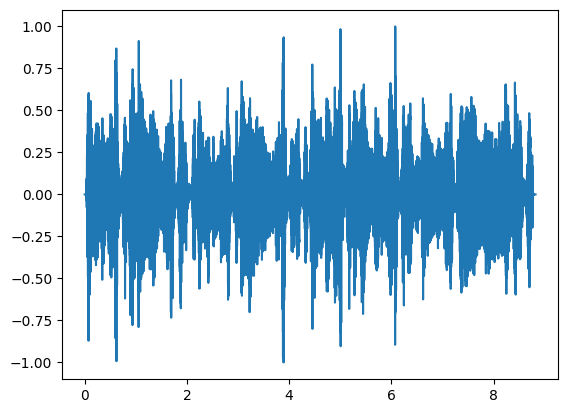

In [3]:
wave = thinkdsp.read_wave(filename=filename)
wave.normalize()
wave.plot()

Выделим из объекта Wave сегмент длиной в 0.4 с.

In [4]:
segment: thinkdsp.Wave = wave.segment(start=2.2, duration=0.7)
segment.make_audio()

Построим график сегмента.

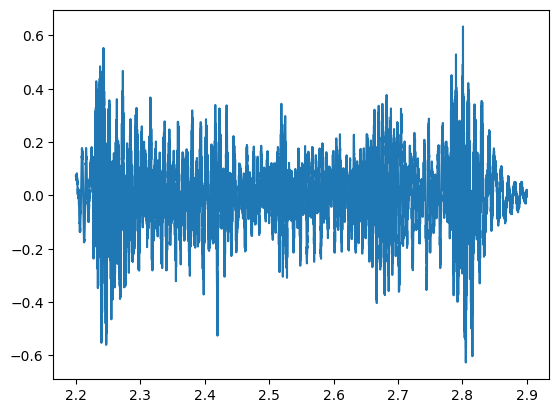

In [5]:
segment.plot()

Построим спектр полученного сегмента. На сегменте виднен максимум амплитуды в районе 140 Гц -- основной тон. Из открытых источников узнаем, что нота ре имеет частоту в  146,83 Гц. Судя по всему, в данном сегменте играется именно эта нота.

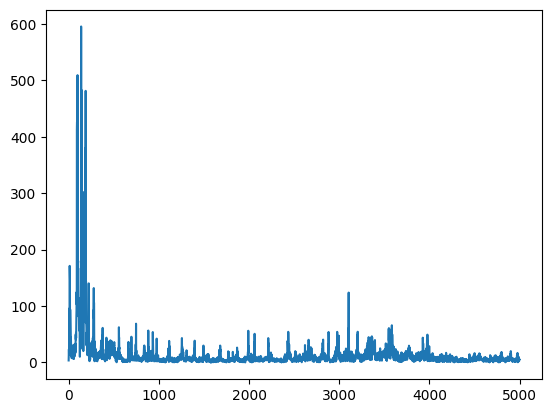

In [6]:
spectrum: thinkdsp.Spectrum = segment.make_spectrum()
spectrum.plot(high=5000)

Узнаем, чему равна частота с наивысшей амплитудой. Полученное значение 595.52 Гц отличается от высоты ноты D₅(ре) (587.33 Гц).

In [7]:
spectrum.peaks()[0]

(np.float64(595.5206159849831), np.float64(138.57142857142856))

Отфильтруем обертона спектра, оставив только те, чьи частоты не превышают 1000. Получим новый спектр. Его звук стал больше напоминать синтезированный звук, тембр скрипки безвозвратно утрачен. Тем не менее, основной тон остался прежним.

In [8]:
spectrum_new: thinkdsp.Spectrum = spectrum.copy()
spectrum_new.low_pass(1000)
spectrum_new.make_wave().make_audio()

Построим полученный спектр, чтобы убедиться, что фильтрация произошла успешно.

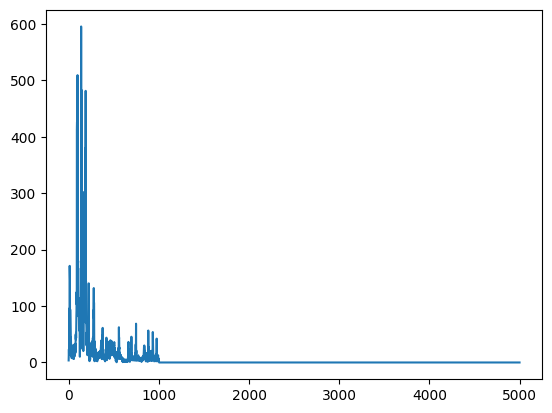

In [9]:
spectrum_new.plot(high=5000)

## Упражнение 1.3

Создадим сложный сигнал на основе синусоидального и косинусоидального сигналов.

In [10]:
sin_sig = thinkdsp.SinSignal(freq=337.87, amp=0.9, offset=0)
cos_sig = thinkdsp.CosSignal(freq=777.23, amp=0.7, offset=0)
mix1: thinkdsp.Signal = sin_sig + cos_sig
mix1_wave: thinkdsp.Wave = mix1.make_wave(duration=0.5, start=0, framerate=6025)
mix1_wave.make_audio()

Построим график небольшого сегмента полученного сигнала.

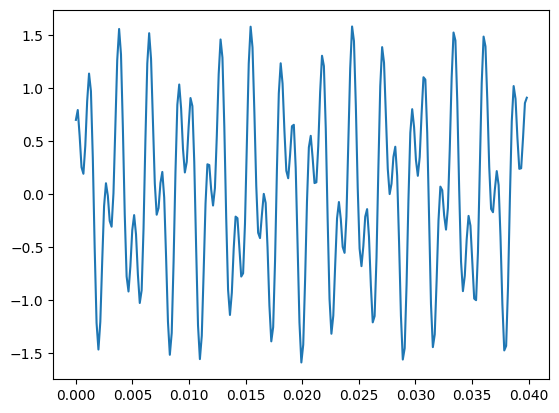

In [11]:
mix1_wave.segment(start=0, duration=0.04).plot()

Также построим спектр сигнала. На нём видно 2 отдельных тона с заданными частотами.

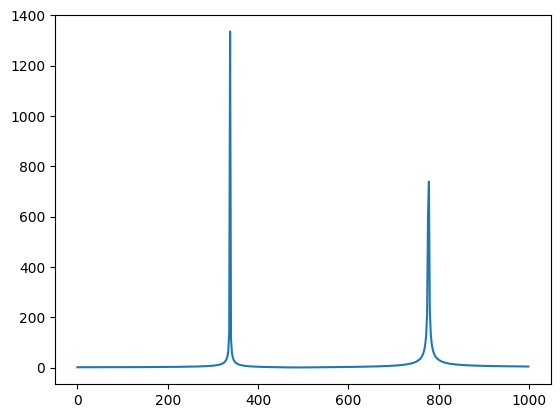

In [12]:
mix1_spectrum: thinkdsp.Spectrum = mix1_wave.make_spectrum()
mix1_spectrum.plot(high=1000)

Добавим к сигналу частотную компоненту, не кратную двум исходным.

In [13]:
mix2 = mix1 + thinkdsp.SinSignal(freq=440, amp=1, offset=0)

Прослушаем полученный сигнал. В полученном звуке чувствуется некоторая напряженность.



In [14]:
mix2_wave: thinkdsp.Wave = mix2.make_wave(duration=0.5, start=0, framerate=6025)
mix2_wave.make_audio()

Построим спектр нового сигнала с частотной компонентой, не кратной основным. На графике появился новый пик с заданной частотой, однако видно, что его симметрия нарушена.

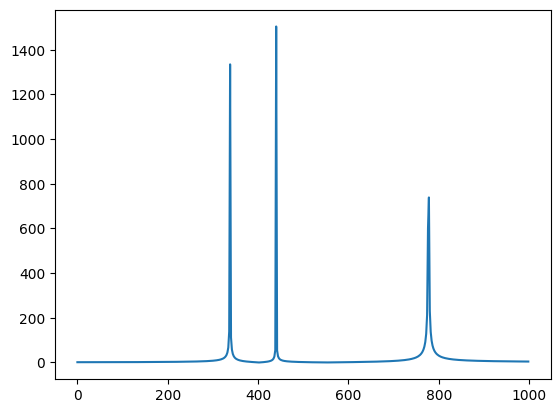

In [15]:
mix2_spectrum: thinkdsp.Spectrum = mix2_wave.make_spectrum()
mix2_spectrum.plot(high=1000)

## Упражнение 1.4

Создадим функцию stretch, способную ускорять или замедлять сигнал. Для этого умножим NumPy-массив, доступный из атрибута ts, на k, а значение framerate поделим на k, так как при увеличении скорости в 2 раза требуется в 2 раза меньше "кадров" и наоборот.

In [16]:
def stretch(w: thinkdsp.Wave, k: float) -> thinkdsp.Wave:
  w.ts *= k
  w.framerate /= k*1.5

Протестируем функцию stretch на аудиофайле со скрипкой.

In [17]:
wv: thinkdsp.Wave = thinkdsp.read_wave(filename='./audio/guitar.wav')
wv.make_audio()

Полученный файл имеет увелченную скорость и увеличенный тон.

In [18]:
stretch(wv, 0.5)
wv.make_audio()